## در این مثال داده های کارهای تعمیراتی بر روی یک مجموعه کمپرسور استفاده شده است. دیتاست را از آدرس زیر دانلود و در پوشه کاری قرار دهید
https://github.com/hojatollahgholami/AI-in-Oil-and-gas-industry/blob/main/ex4-3/CompressorsWorks.csv

### فراخوانی کتابخانه ها

In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import jdatetime

### تابع تبدیل تاریخ شمسی به میلادی

In [2]:
def convert_to_gregorian(shamsi_date):
    x = str(shamsi_date)
    year=x[0:4]
    month=x[4:6]
    day =x[6:8]
    return jdatetime.date(int(year),int(month),int(day)).togregorian()

### فراخوانی داده و تنظیم زمان

In [3]:
df = pd.read_csv("CompressorsWorks.csv")
df['WO Start Date'] = df['WO Start Date'].apply(convert_to_gregorian)
df['WO End Date'] = df['WO End Date'].apply(convert_to_gregorian)
df['Request Date'] = df['Request Date'].apply(convert_to_gregorian)
df["Request Delay"] = (df["WO Start Date"]-df["Request Date"])
df['Duration'] = (df["WO End Date"]-df["WO Start Date"])
df['Parent'] = df['Code'].apply(lambda x:'/'.join(x.split('/')[:-1]) if "/" in x else None)
 # اگر زمان شروع و پایان کار در یک روز باشد باید از ساعت کارکرد استفاده شود
mask = df['Duration'] == pd.Timedelta(0)
df.loc[mask, "Duration"] = pd.to_timedelta(df.loc[mask,'Total Hours Work']/24, unit="D") 
df['Duration'] = pd.to_timedelta(df['Duration'])
df['Duration_days'] = df['Duration'].dt.total_seconds() / (24*3600) 
df.loc[df['Duration_days']<1, "Duration_days"] *=3 # یک روز کایر 8 ساعت است
df.head()

,Code,Tag No,Equipment Class,Trade,Work Type,Request Date,WO Start Date,WO End Date,Total Hours Work,Request Delay,Duration,Parent,Duration_days
0,111201/1/2,Comp_E,ELECTRIC MOTOR,WORKSHOP,CORRECTIVE,2021-03-24,2021-03-28,2021-03-31,14,"4 days, 0:00:00",3 days 00:00:00,111201/1,3.000
1,110295/7,Comp_D,COMPRESSOR,ELECTRICAL,PREVENTIVE MAINTENANCE,2021-03-22,2021-03-23,2021-03-23,6,"1 day, 0:00:00",0 days 06:00:00,110295,0.750
2,110295/6,Comp_D,COMPRESSOR,WORKSHOP,PREVENTIVE MAINTENANCE,2021-03-22,2021-03-23,2021-03-24,6,"1 day, 0:00:00",1 days 00:00:00,110295,1.000
3,201496,Comp_B,COMPRESSOR,FIX MECHANICAL,CORRECTIVE,2026-02-28,2026-02-28,2026-02-28,5,0:00:00,0 days 04:59:59.999999997,None,0.625
4,201391,Comp_B,COMPRESSOR,MACHINERY,CORRECTIVE,2026-02-25,2026-02-27,2026-02-27,3,"2 days, 0:00:00",0 days 03:00:00,None,0.375


In [4]:
Tags = set(df['Tag No'].unique())
Tags

{'Comp_A', 'Comp_B', 'Comp_C', 'Comp_D', 'Comp_E'}

In [5]:
Trades = set(df['Trade'].unique())
Trades

{'CRAFT',
 'Condition Monitoring',
 'ELECTRICAL',
 'FIX MECHANICAL',
 'INSTRUMENT',
 'MACHINERY',
 'MECHANICAL SHIFT',
 'OVERHAUL',
 'WORKSHOP'}

### نمایش کارهای تعمیراتی به تفکیک تیم های تعمیراتی

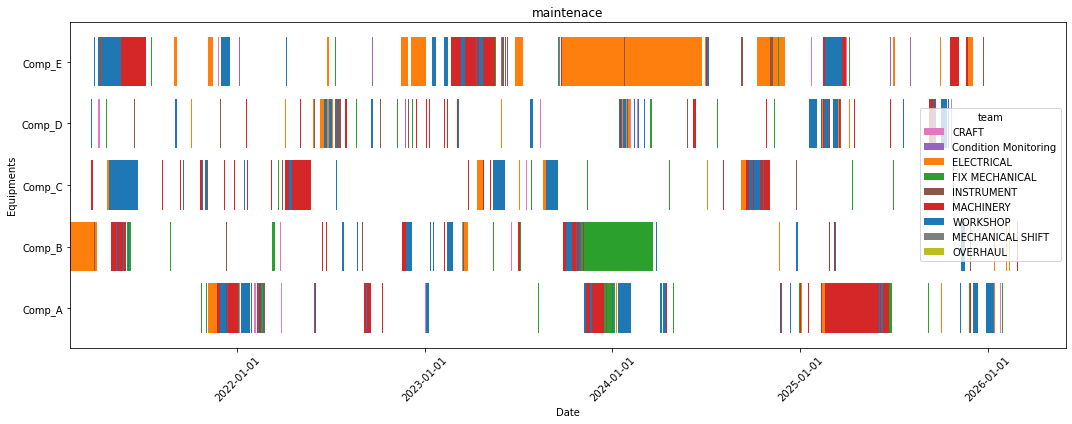

In [6]:
trades = df['Trade'].unique()
cmap = plt.cm.tab20
trade_colors = {t: cmap(i*2) for i, t in enumerate(trades)}
used_labels = set()

df["WO Start Date"] = pd.to_datetime(df['WO Start Date'])

fig,ax=plt.subplots(figsize=(15,6))
for (equipment,trade), g in df.groupby(['Tag No','Trade']):
    trade=g['Trade'].iloc[0]
    label = trade if trade not in used_labels else None
    used_labels.add(trade)
    ax.barh(y=[equipment]*len(g), 
            width=g['Duration_days'],
            left=g['WO Start Date'],
            color=trade_colors[trade],
            label =label
           )
ax.legend(title='team')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Equipments')
plt.title('maintenace')
#plt.legend(title='team')
plt.tight_layout()
plt.savefig('1.png',dpi=300)
plt.show()

### نمایش کارهای تعمیراتی براساس تاخیر در شروع کار تعمیراتی

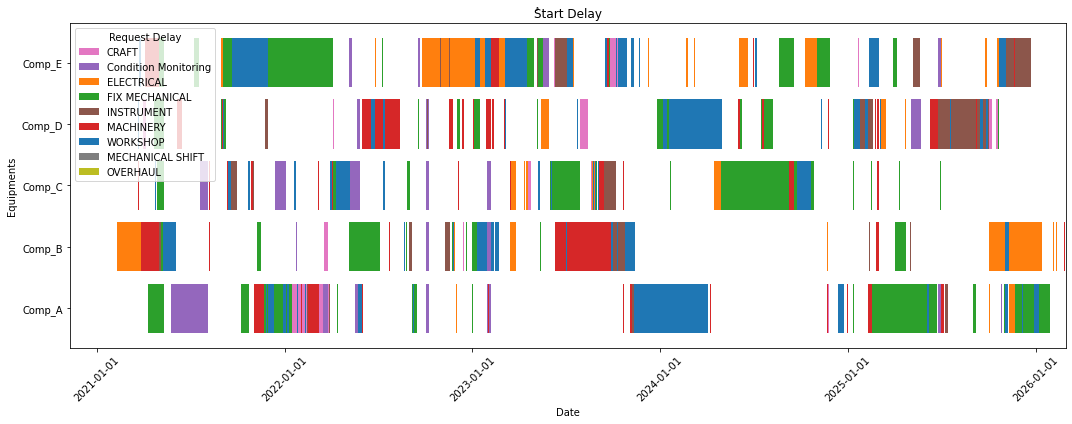

In [7]:
trades = df['Trade'].unique()
cmap = plt.cm.tab20
trade_colors = {t: cmap(2*i) for i, t in enumerate(trades)}
used_labels = set()

fig,ax=plt.subplots(figsize=(15,6))
for (equipment,trade), g in df.groupby(['Tag No','Trade']):
    trade=g['Trade'].iloc[0]
    label = trade if trade not in used_labels else None
    used_labels.add(trade)
    ax.barh(y=[equipment]*len(g), 
            width=g['Request Delay'],
            left=g['Request Date'],
            color=trade_colors[trade],
            label =label
           )
ax.legend(title='Request Delay')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Equipments')
plt.title('ُStart Delay')
#plt.legend(title='team')
plt.tight_layout()
plt.savefig('2.png',dpi=300)
plt.show()

### نمایش کارهای تعمیراتی به تفکیک نوع کار تعمیراتی

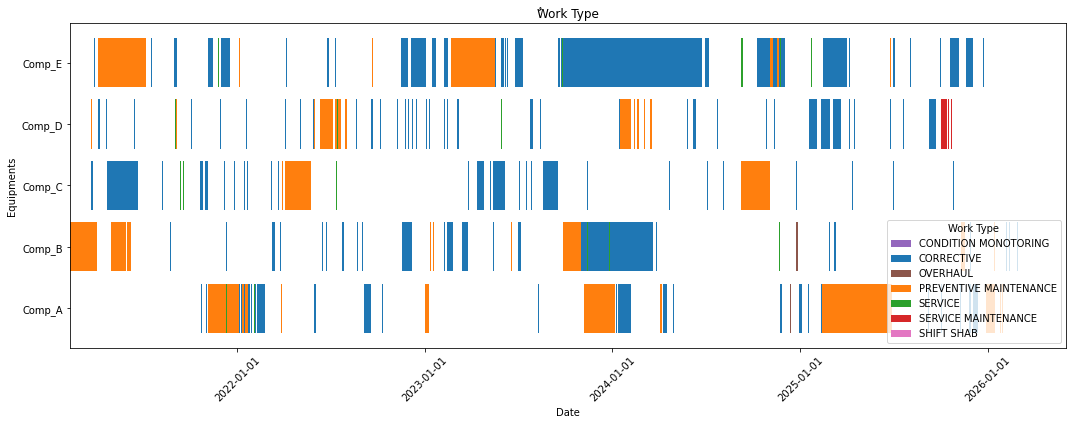

In [8]:
WO = df['Work Type'].unique()
cmap = plt.cm.tab20
WO_colors = {t: cmap(i*2) for i, t in enumerate(WO)}
used_labels = set()

df["WO Start Date"] = pd.to_datetime(df['WO Start Date'])

fig,ax=plt.subplots(figsize=(15,6))
for (equipment,WO_Type), g in df.groupby(['Tag No','Work Type']):
    WO_Type=g['Work Type'].iloc[0]
    label = WO_Type if WO_Type not in used_labels else None
    used_labels.add(WO_Type)
    ax.barh(y=[equipment]*len(g), 
            width=g['Duration_days'],
            left=g['WO Start Date'],
            color=WO_colors[WO_Type],
            label =label
           )
ax.legend(title='Work Type')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Equipments')
plt.title('ٌWork Type')
#plt.legend(title='team')
plt.tight_layout()
plt.savefig('3.png',dpi=300)
plt.show()

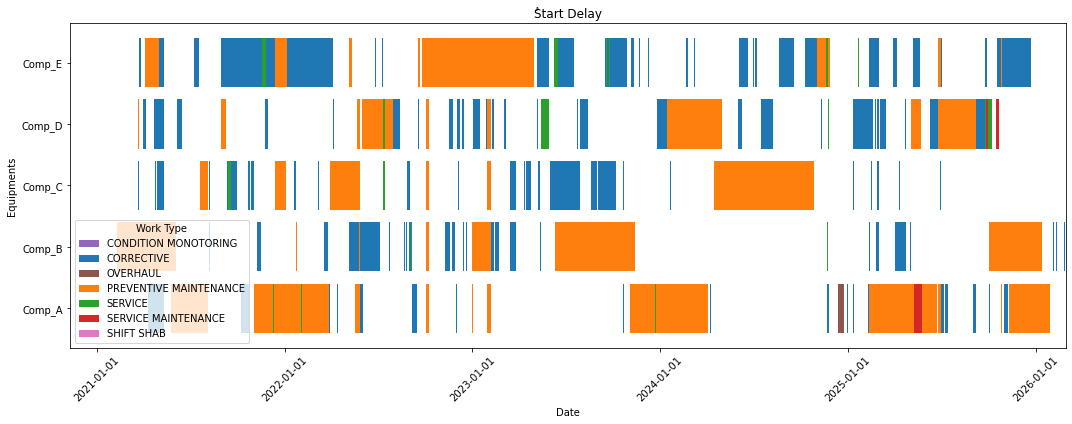

In [9]:
WO = df['Work Type'].unique()
cmap = plt.cm.tab20
WO_colors = {t: cmap(2*i) for i, t in enumerate(WO)}
used_labels = set()

fig,ax=plt.subplots(figsize=(15,6))
for (equipment,trade), g in df.groupby(['Tag No','Work Type']):
    WO=g['Work Type'].iloc[0]
    label = WO if WO not in used_labels else None
    used_labels.add(WO)
    ax.barh(y=[equipment]*len(g), 
            width=g['Request Delay'],
            left=g['Request Date'],
            color=WO_colors[WO],
            label =label
           )
ax.legend(title='Work Type')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Equipments')
plt.title('ُStart Delay')
plt.tight_layout()
plt.savefig('4.png',dpi=300)
plt.show()

## شناسایی تیم های گلوگاه تعمیراتی
به این منظور گزارش حجم کاری، میانگین تاخیرها و تعداد کار تعمیراتی هر تیم استخراج می شود

#### گزارش حجم کاری تیم های تعمیراتی

In [10]:
df.groupby("Trade")["Total Hours Work"].sum().sort_values(ascending=False)

Trade
ELECTRICAL              3635
MACHINERY               3282
FIX MECHANICAL          2681
WORKSHOP                2265
CRAFT                   1738
INSTRUMENT               888
Condition Monitoring     293
OVERHAUL                  40
MECHANICAL SHIFT          15
Name: Total Hours Work, dtype: int64

#### گزارش میانگین تاخیر هر تیم تعمیراتی

In [11]:
df.groupby("Trade")["Request Delay"].sum().sort_values(ascending=False)

Trade
FIX MECHANICAL         2258 days
ELECTRICAL             2181 days
WORKSHOP                647 days
INSTRUMENT              484 days
CRAFT                   403 days
MACHINERY               399 days
Condition Monitoring    269 days
OVERHAUL                  9 days
MECHANICAL SHIFT          0 days
Name: Request Delay, dtype: timedelta64[ns]

#### تعداد کار هر تیم

In [12]:
df['Trade'].value_counts()

Trade
ELECTRICAL              270
WORKSHOP                230
FIX MECHANICAL          204
CRAFT                   183
INSTRUMENT              144
MACHINERY               115
Condition Monitoring    115
MECHANICAL SHIFT          4
OVERHAUL                  1
Name: count, dtype: int64

### چیدمان زمان درگیری تیم های تعمیراتی

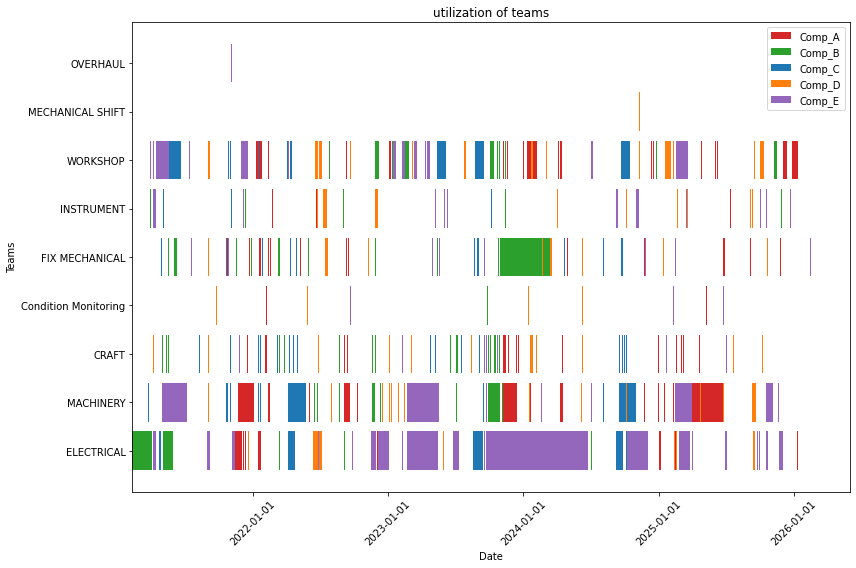

In [13]:
df = df.sort_values(['Trade','WO Start Date'])

tags = df['Tag No'].unique()
cmap = plt.cm.tab20
tags_colors = {t: cmap(i*2) for i, t in enumerate(tags)}
used_labels = set()

fig, ax = plt.subplots(figsize=(12,8))
for (equipment,trade), g in df.groupby(['Tag No','Work Type']):
    tag=g['Tag No'].iloc[0]
    label = tag if tag not in used_labels else None
    used_labels.add(tag)
    ax.barh(
            g['Trade'],
            g['Duration_days'],
            left=g['WO Start Date'],
            color=tags_colors[tag],
            label=label
            )
ax.set_xlabel('Date')
ax.set_ylabel('Teams')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.title('utilization of teams')
plt.legend()
plt.tight_layout()
plt.savefig('5.png',dpi=300)
plt.show()

### با نمایش وابستگی تیم ها به یکدیگر

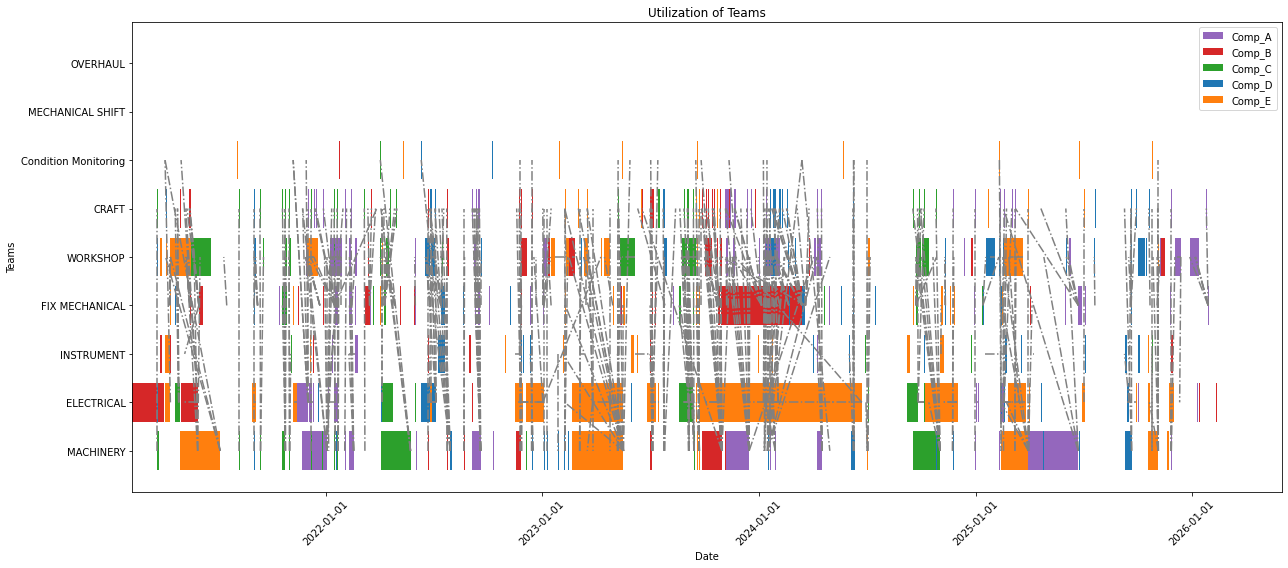

In [14]:
df = df.sort_values(['Code','WO Start Date'])

tags = df['Tag No'].unique()
cmap = plt.cm.tab20
tags_colors = {t: cmap(i*2) for i, t in enumerate(tags)}
used_labels = set()

fig, ax = plt.subplots(figsize=(18,8))
for (equipment,trade), g in df.groupby(['Tag No','Work Type']):
    for _,row in g.iterrows():
        tag=row['Tag No']
        label = tag if tag not in used_labels else None
        used_labels.add(tag)
        ax.barh(
            row['Trade'],
            row['Duration_days'],
            left=row['WO Start Date'],
            color=tags_colors[tag],
            label=label
                )
        if row['Parent'] in df['Code'].values:
            parent = df[df['Code']==row['Parent']].iloc[0]
        
            ax.plot(
                [parent["WO End Date"], row['WO Start Date']],
                [parent['Trade'], row['Trade']],
                color='gray',
                linestyle='-.'
                    )
ax.set_xlabel('Date')
ax.set_ylabel('Teams')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.title('Utilization of Teams')
plt.legend()
plt.tight_layout()
plt.savefig('6.png',dpi=300)
plt.show()

با توجه به گزارش ها، تیم برق بیشترین درگیری کاری را برای مجموعه کمپرسورها داشته است. از طرفی تیم تعمیرات تجهیزات ثابت دارای تاخیرات زیادی است که می تواند ناشی از کمبود نفرات در این بخش باشد. 

### محاسبه وابستگی تیم های تعمیراتی به یکدیگر

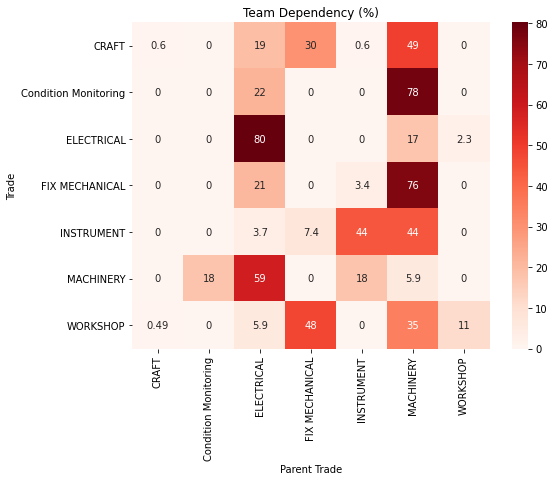

Parent Trade,CRAFT,Condition Monitoring,ELECTRICAL,FIX MECHANICAL,INSTRUMENT,MACHINERY,WORKSHOP
Trade,,,,,,,
CRAFT,0.602410,0.000000,19.277108,30.120482,0.602410,49.397590,0.000000
Condition Monitoring,0.000000,0.000000,21.739130,0.000000,0.000000,78.260870,0.000000
ELECTRICAL,0.000000,0.000000,80.232558,0.000000,0.000000,17.441860,2.325581
FIX MECHANICAL,0.000000,0.000000,20.689655,0.000000,3.448276,75.862069,0.000000
INSTRUMENT,0.000000,0.000000,3.703704,7.407407,44.444444,44.444444,0.000000
MACHINERY,0.000000,17.647059,58.823529,0.000000,17.647059,5.882353,0.000000
WORKSHOP,0.487805,0.000000,5.853659,47.804878,0.000000,34.634146,11.219512


In [26]:
parent_trade = df.set_index('Code')['Trade']
df['Parent Trade'] = df['Parent'].map(parent_trade)

dependency = df.dropna(subset=['Parent Trade'])
matrix = pd.crosstab(dependency['Trade'], dependency['Parent Trade'])

dependency_percent = matrix.div(matrix.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8,6))
sns.heatmap(dependency_percent, annot=True, cmap='Reds')
plt.title('Team Dependency (%)')
plt.show()

dependency_percent